In [9]:
path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_score_outputs/eterna_data"

In [10]:
import os

model_score_map = {}
for f in os.listdir(path):
    model = f.split(".")[0]
    with open(f"{path}/{f}") as fh:
        scores = [float(s) for s in fh.read().split(",")]
    model_score_map[model] = scores

model_score_map.keys()

dict_keys(['ContextFold', 'MXFold2', 'IPKnot', 'RNAStructure', 'SPOT-RNA', 'RNAFold', 'NUPACK', 'ContraFold', 'Simfold', 'EternaFold', 'pKnots', 'MXFold', 'NeuralFold'])

In [11]:
model_score_map["ContextFold"][:10]

[0.5396825396825397,
 0.5303030303030303,
 0.8412698412698413,
 0.8769230769230769,
 0.7627118644067796,
 0.7777777777777778,
 0.8412698412698413,
 0.8636363636363636,
 0.8709677419354839,
 0.9183673469387755]

In [12]:
import data_utils as du

def detect_dataset(line):
    ds = line[0]
    if ds == "RNAndria":
        if line[2].startswith("hsa"):
            return "RNAndria pri-miRNA"
        else:
            return "RNAndria mRNA"
    else:
        return ds

with open("data/chemical_mapping_master_file.txt") as fh:
    dsci_data = fh.readlines()

dsci_data = [d.split(", ") for d in dsci_data]

dsci_scores = {}
for ds in du.chemical_mapping_datasets:
    if ds != "EternaData":
        continue
    for m in du.models:
        dsci_scores[m] = []

for d in dsci_data:
    ds = detect_dataset(d)
    model = d[1]
    acc = float(d[5])
    dsci_scores[model].append(acc)



ds_model_map = {"EternaData (Eterna Scorer)": model_score_map, "EternaData (DSCI Scorer)": dsci_scores}

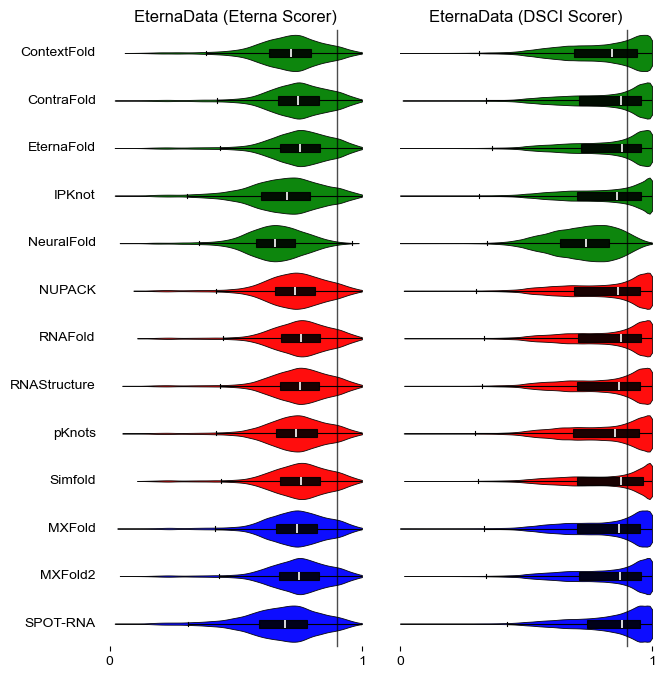

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

dataset_order = ["EternaData (Eterna Scorer)", "EternaData (DSCI Scorer)"]

n_rows = len(model_order)
n_cols = len(dataset_order)

fig_w = max(1.8 * n_cols, 7)
fig_h = max(0.4 * n_rows, 8)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_w, fig_h),
    squeeze=False,
    sharex=False,
    sharey=False
)

for row_idx, model in enumerate(model_order):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    for col_idx, dataset in enumerate(dataset_order):
        ax = axes[row_idx, col_idx]

        values = ds_model_map.get(dataset, {}).get(model, [])
        values = [v for v in values if v is not None and not np.isnan(v)]

        violin = ax.violinplot(
            values,
            positions=[0],
            widths=0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False,
            vert=False
        )

        model_color = du.get_model_color(model)

        for body in violin["bodies"]:
            body.set_facecolor(model_color)
            body.set_edgecolor("black")
            body.set_alpha(0.95)
            body.set_linewidth(0.6)

        # Add inner boxplot inside the violin
        box = ax.boxplot(
            values,
            positions=[0],
            widths=0.18,
            vert=False,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(
                facecolor="black",
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9
            ),
            medianprops=dict(
                color="white",
                linewidth=1.2
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8
            ),
            capprops=dict(
                color="black",
                linewidth=0.8
            )
        )

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.0)


        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.5, 0.5)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
        else:
            ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(False)

        if col_idx == 0:
            ax.set_ylabel(model, rotation=0, ha="right", va="center", labelpad=10)

        if row_idx == 0:
            ax.set_title(dataset)

# plt.tight_layout()
# 2d line
plt.subplots_adjust(hspace=0.05, wspace=0.15)

fig.canvas.draw()

threshold = 0.9

for col_idx in range(n_cols):
    top_ax = axes[0, col_idx]
    bottom_ax = axes[-1, col_idx]

    # Convert x=0.9 from data coordinates to figure coordinates
    x_display = top_ax.transData.transform((threshold, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]

    # Get vertical span of the whole column in figure coordinates
    y_bottom = bottom_ax.get_position().y0
    y_top = top_ax.get_position().y1

    line = Line2D(
        [x_fig, x_fig],
        [y_bottom, y_top],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.7,
        zorder=10
    )

    fig.add_artist(line)

# plt.savefig("chem_mapping_violin_plot.png", dpi=500)
plt.show()

In [14]:
print("Average scores:")
for m in du.models:
    e_scores = ds_model_map["EternaData (Eterna Scorer)"][m]
    d_scores = ds_model_map["EternaData (DSCI Scorer)"][m]
    eavg = round((sum(e_scores) / len(e_scores)), 4)
    davg = round((sum(d_scores) / len(d_scores)), 4)
    print(f"{m}:")
    print(f"Eterna Scorer: {eavg}\tDSCI Scorer: {davg}")


Average scores:
ContextFold:
Eterna Scorer: 0.7076	DSCI Scorer: 0.8032
ContraFold:
Eterna Scorer: 0.7353	DSCI Scorer: 0.8227
EternaFold:
Eterna Scorer: 0.7427	DSCI Scorer: 0.8265
IPKnot:
Eterna Scorer: 0.6895	DSCI Scorer: 0.8176
MXFold:
Eterna Scorer: 0.7314	DSCI Scorer: 0.8172
MXFold2:
Eterna Scorer: 0.7389	DSCI Scorer: 0.8231
NeuralFold:
Eterna Scorer: 0.6509	DSCI Scorer: 0.727
NUPACK:
Eterna Scorer: 0.7258	DSCI Scorer: 0.8143
pKnots:
Eterna Scorer: 0.7293	DSCI Scorer: 0.8087
RNAFold:
Eterna Scorer: 0.7466	DSCI Scorer: 0.8215
RNAStructure:
Eterna Scorer: 0.7425	DSCI Scorer: 0.818
Simfold:
Eterna Scorer: 0.7449	DSCI Scorer: 0.8235
SPOT-RNA:
Eterna Scorer: 0.6787	DSCI Scorer: 0.8332
